# Image inspection and Conversion
I would like to do this seperately before running the model. Manually converting and checking images so they are in correct format and can feed into the model directly.

## Loading files from local to RetiFluidNet folder

In [3]:
from pathlib import Path
import shutil
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

source_base = Path(r'D:\GradApp\BIDS@I2DB\lab_works\RETOUCH\RETOUCH-TrainingSet-Topcon')  # Change it to where you save the files locally
dest_bscan   = Path(r'C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\raw_bscans')
dest_mask    = Path(r'C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\raw_masks')

dest_bscan.mkdir(parents=True, exist_ok=True)
dest_mask.mkdir(parents=True, exist_ok=True)

mapping = [
    ('oct', dest_bscan, '_oct'),
    ('reference', dest_mask,  '_mask'),
]

for idx in range(49, 71):
    train_id = f'TRAIN{idx:03d}'
    src_dir = source_base / train_id

    for src_stem, dest_dir, suffix in mapping:
        src_mhd = src_dir / f"{src_stem}.mhd"
        src_raw = src_dir / f"{src_stem}.raw"

        dest_mhd = dest_dir / f"{train_id}{suffix}.mhd"
        dest_raw = dest_dir / f"{train_id}{suffix}.raw"

        shutil.copy2(src_mhd, dest_mhd)
        text = dest_mhd.read_text().splitlines()
        with open(dest_mhd, 'w', newline='\n') as f:
            for line in text:
                if line.strip().startswith('ElementDataFile'):
                    f.write(f"ElementDataFile = {dest_raw.name}\n")
                else:
                    f.write(line + "\n")

        if src_raw.exists():
            shutil.copy2(src_raw, dest_raw)
            print(f"Copied files to {dest_raw.name}")
        else:
            print(f"Files not found: {src_raw}")

Copied files to TRAIN049_oct.raw
Copied files to TRAIN049_mask.raw
Copied files to TRAIN050_oct.raw
Copied files to TRAIN050_mask.raw
Copied files to TRAIN051_oct.raw
Copied files to TRAIN051_mask.raw
Copied files to TRAIN052_oct.raw
Copied files to TRAIN052_mask.raw
Copied files to TRAIN053_oct.raw
Copied files to TRAIN053_mask.raw
Copied files to TRAIN054_oct.raw
Copied files to TRAIN054_mask.raw
Copied files to TRAIN055_oct.raw
Copied files to TRAIN055_mask.raw
Copied files to TRAIN056_oct.raw
Copied files to TRAIN056_mask.raw
Copied files to TRAIN057_oct.raw
Copied files to TRAIN057_mask.raw
Copied files to TRAIN058_oct.raw
Copied files to TRAIN058_mask.raw
Copied files to TRAIN059_oct.raw
Copied files to TRAIN059_mask.raw
Copied files to TRAIN060_oct.raw
Copied files to TRAIN060_mask.raw
Copied files to TRAIN061_oct.raw
Copied files to TRAIN061_mask.raw
Copied files to TRAIN062_oct.raw
Copied files to TRAIN062_mask.raw
Copied files to TRAIN063_oct.raw
Copied files to TRAIN063_mask

In [5]:
print("Current working directory:", os.getcwd())

# MHD header reader
def read_mhd_header(mhd_path):
    header = {}
    with open(mhd_path, 'r') as f:
        for line in f:
            line = line.strip()
            if '=' in line:
                key, val = line.split('=', 1)
                header[key.strip()] = val.strip()
    return header

# Read raw volume into NumPy array and reshape to Z, Y, X
def read_mhd_volume(mhd_path):
    hdr = read_mhd_header(mhd_path)
    dim_x, dim_y, dim_z = map(int, hdr['DimSize'].split())
    dtype_map = {
        'MET_UCHAR':  np.uint8,  'MET_USHORT': np.uint16,
    }
    et = hdr.get('ElementType', 'MET_UCHAR')
    raw_path = mhd_path.parent / hdr['ElementDataFile']
    arr = np.fromfile(raw_path, dtype=dtype_map[et])
    vol = arr.reshape((dim_z, dim_y, dim_x))
    return vol, hdr

Current working directory: C:\Users\sunxi\RetiFluidNet_CPU


In [7]:
# Check file directory 
topcon = Path(os.getcwd()) / 'RetouchData' / 'Topcon' 
raw_oct_dir = topcon / 'raw_bscans'
raw_mask_dir = topcon / 'raw_masks'

print("OCT files in raw_bscans:")
for f in sorted(raw_oct_dir.glob('*.mhd')):
    print('-', f.name)
print("\nMask files in raw_masks:")
for f in sorted(raw_mask_dir.glob('*.mhd')):
    print('-', f.name)

OCT files in raw_bscans:
- TRAIN049_oct.mhd
- TRAIN050_oct.mhd
- TRAIN051_oct.mhd
- TRAIN052_oct.mhd
- TRAIN053_oct.mhd
- TRAIN054_oct.mhd
- TRAIN055_oct.mhd
- TRAIN056_oct.mhd
- TRAIN057_oct.mhd
- TRAIN058_oct.mhd
- TRAIN059_oct.mhd
- TRAIN060_oct.mhd
- TRAIN061_oct.mhd
- TRAIN062_oct.mhd
- TRAIN063_oct.mhd
- TRAIN064_oct.mhd
- TRAIN065_oct.mhd
- TRAIN066_oct.mhd
- TRAIN067_oct.mhd
- TRAIN068_oct.mhd
- TRAIN069_oct.mhd
- TRAIN070_oct.mhd

Mask files in raw_masks:
- TRAIN049_mask.mhd
- TRAIN050_mask.mhd
- TRAIN051_mask.mhd
- TRAIN052_mask.mhd
- TRAIN053_mask.mhd
- TRAIN054_mask.mhd
- TRAIN055_mask.mhd
- TRAIN056_mask.mhd
- TRAIN057_mask.mhd
- TRAIN058_mask.mhd
- TRAIN059_mask.mhd
- TRAIN060_mask.mhd
- TRAIN061_mask.mhd
- TRAIN062_mask.mhd
- TRAIN063_mask.mhd
- TRAIN064_mask.mhd
- TRAIN065_mask.mhd
- TRAIN066_mask.mhd
- TRAIN067_mask.mhd
- TRAIN068_mask.mhd
- TRAIN069_mask.mhd
- TRAIN070_mask.mhd


## Grab an example and investigate

In [10]:
# Load an example patient (61)
example_oct = sorted(raw_oct_dir.glob('*.mhd'))[12]
oct_vol, oct_hdr = read_mhd_volume(example_oct)
mask_path = raw_mask_dir / example_oct.name.replace('_oct.mhd', '_mask.mhd')
mask_vol, mask_hdr = read_mhd_volume(mask_path)

print(f"Loaded OCT: {example_oct.name}")
print(f"OCT shape (Z, Y, X): {oct_vol.shape}")
print(f"OCT sum: {np.sum(oct_vol)}")
print("OCT intensity range:", oct_vol.min(), "to", oct_vol.max())
print(oct_hdr)


print(f"Mask shape (Z, Y, X): {mask_vol.shape}")
print(f"Mask sum: {np.sum(mask_vol)}")
print("Mask labels range:", mask_vol.min(), "to", mask_vol.max())
print(mask_hdr)

Loaded OCT: TRAIN061_oct.mhd
OCT shape (Z, Y, X): (128, 650, 512)
OCT sum: 2764357327
OCT intensity range: 0 to 255
{'ObjectType': 'Image', 'NDims': '3', 'BinaryData': 'True', 'BinaryDataByteOrderMSB': 'False', 'CompressedData': 'False', 'TransformMatrix': '1  0  0  0  1  0  0  0  1', 'CenterOfRotation': '0  0  0', 'AnatomicalOrientation': 'RAI', 'Offset': '0  0  0', 'ElementSpacing': '0.01172       0.0026      0.04688', 'DimSize': '512  650  128', 'ElementNumberOfChannels': '1', 'ElementType': 'MET_UCHAR', 'ElementDataFile': 'TRAIN061_oct.raw'}
Mask shape (Z, Y, X): (128, 650, 512)
Mask sum: 1537008
Mask labels range: 0 to 3
{'ObjectType': 'Image', 'NDims': '3', 'BinaryData': 'True', 'BinaryDataByteOrderMSB': 'False', 'CompressedData': 'False', 'TransformMatrix': '1  0  0  0  1  0  0  0  1', 'CenterOfRotation': '0  0  0', 'AnatomicalOrientation': 'RAI', 'Offset': '0  0  0', 'ElementSpacing': '0.01172       0.0026      0.04688', 'DimSize': '512  650  128', 'ElementNumberOfChannels': '1

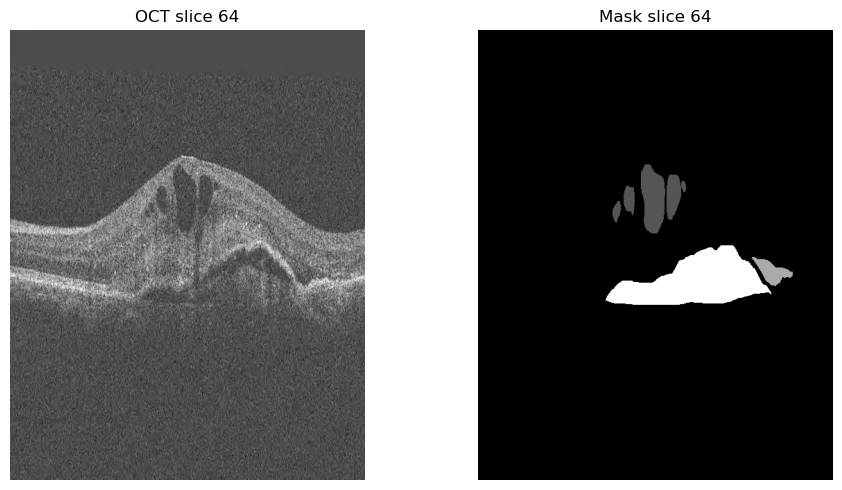

In [10]:
# Visualize Slices
slice_idx = 64
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(oct_vol[slice_idx], cmap='gray')
axes[0].set_title(f'OCT slice {slice_idx}')
axes[0].axis('off')

axes[1].imshow(mask_vol[slice_idx], cmap='gray')
axes[1].set_title(f'Mask slice {slice_idx}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## original OCT bscans

In [12]:
# Full matrix for OCT bscan
print("OCT slice matrix at slice", slice_idx)
print(f"OCT sum: {np.sum(oct_vol[slice_idx])}")
print(oct_vol[24][150:300])

OCT slice matrix at slice 64
OCT sum: 22008670
[[ 58  56  53 ...  77  49  28]
 [ 42  50  59 ...  66  57  51]
 [ 28  48  66 ...  52  66  76]
 ...
 [148 150 152 ...  88 124 133]
 [108  99 110 ... 139  92 127]
 [ 94 119 114 ... 135 117 115]]


## original masks come with pixel of range [0, 1, 2, 3]

In [15]:
# Matrix of masks
np.set_printoptions(threshold=np.inf)
print("Mask slice matrix at slice index:", slice_idx)
print(f"Mask sum: {np.sum(mask_vol[slice_idx])}")
print(mask_vol[24][150:300])

Mask slice matrix at slice index: 64
Mask sum: 41691
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

## Convert the raw images to the format the model want, bscan to jpg, masks to gif

In [18]:
# Image conversion, from raw to jpg and gif
oct_root      = topcon / 'retouch_data'
mask_root     = topcon / 'retouch_data_mask'
gray_levels   = np.array([0, 85, 170, 255], dtype=np.uint8)

for oct_mhd in sorted(raw_oct_dir.glob('*_oct.mhd')):
    stem = oct_mhd.stem.replace('_oct', '') 

    # Load volumes for this patient
    oct_vol, _    = read_mhd_volume(oct_mhd)
    mask_path     = raw_mask_dir / f"{stem}_mask.mhd"
    mask_vol, _   = read_mhd_volume(mask_path)

    # Make patient subdirs
    patient_oct_dir  = oct_root / stem
    patient_mask_dir = mask_root / stem
    patient_oct_dir.mkdir(parents=True, exist_ok=True)
    patient_mask_dir.mkdir(parents=True, exist_ok=True)

    oct_min, oct_max = oct_vol.min(), oct_vol.max()

    for z in range(oct_vol.shape[0]):
        # OCT to JPG
        slice_img = oct_vol[z].astype(np.float32)
        norm      = (slice_img - oct_min) / (oct_max - oct_min)
        jpg       = (norm * 255.0).clip(0,255).astype(np.uint8)
        Image.fromarray(jpg, mode='L') \
             .save(patient_oct_dir / f"{stem}_oct_{z:03d}.jpg")

        # Mask to GIF (0,85,170,255)
        labels = mask_vol[z].astype(np.uint8)
        gray   = gray_levels[labels]
        Image.fromarray(gray, mode='L') \
             .save(patient_mask_dir / f"{stem}_mask_{z:03d}.gif")

    print(f"Patient {stem}: saved {oct_vol.shape[0]} slices to\n"
          f"  OCT JPGs → {patient_oct_dir}\n"
          f"  Mask GIFs → {patient_mask_dir}")

Patient TRAIN049: saved 128 slices to
  OCT JPGs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\retouch_data\TRAIN049
  Mask GIFs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\retouch_data_mask\TRAIN049
Patient TRAIN050: saved 128 slices to
  OCT JPGs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\retouch_data\TRAIN050
  Mask GIFs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\retouch_data_mask\TRAIN050
Patient TRAIN051: saved 128 slices to
  OCT JPGs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\retouch_data\TRAIN051
  Mask GIFs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\retouch_data_mask\TRAIN051
Patient TRAIN052: saved 128 slices to
  OCT JPGs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\retouch_data\TRAIN052
  Mask GIFs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\retouch_data_mask\TRAIN052
Patient TRAIN053: saved 128 slices to
  OCT JPGs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Topcon\retouch_data\TRAIN053
  Mask GIFs 

## Check the converted images

OCT JPG slice 64:
Shape: (650, 512) Sum: 22003449
Mask GIF slice 64:
Shape: (650, 512) Sum: 3543735
Unique gray levels: [  0  85 170 255]


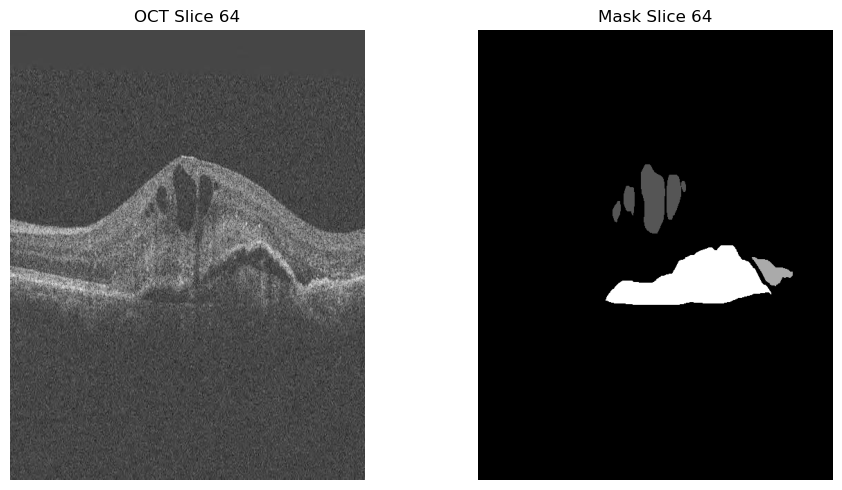

Mask
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    

In [20]:
example = 'TRAIN061'

jpg_path = oct_root  / example / f"{example}_oct_{slice_idx:03d}.jpg"
gif_path = mask_root / example / f"{example}_mask_{slice_idx:03d}.gif"

jpg_arr = np.array(Image.open(jpg_path).convert('L'))
gif_arr = np.array(Image.open(gif_path).convert('L'))

np.set_printoptions(threshold=np.inf, linewidth=200)

print(f"OCT JPG slice {slice_idx}:")
print("Shape:", jpg_arr.shape, "Sum:", jpg_arr.sum())

print(f"Mask GIF slice {slice_idx}:")
print("Shape:", gif_arr.shape, "Sum:", gif_arr.sum())
print("Unique gray levels:", np.unique(gif_arr))


# Side‐by‐side plot
plt.figure(figsize=(10, 5))
# OCT
plt.subplot(1, 2, 1)
plt.imshow(jpg_arr, cmap='gray')
plt.title(f'OCT Slice {slice_idx}')
plt.axis('off')
# Mask
plt.subplot(1, 2, 2)
plt.imshow(gif_arr, cmap='gray')
plt.title(f'Mask Slice {slice_idx}')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Mask\n", gif_arr)
print("OCT\n", jpg_arr)